## Comprensión del problema

El objetivo del proyecto es identificar comportamientos anómalos en transacciones bancarias que puedan indicar posibles fraudes.

La base de datos contiene información sobre características de las transacciones, incluyendo:

- Monto de la transacción
- Duración de la transacción
- Número de intentos de login
- Canal de transacción
- Tipo de transacción
- Balance de la cuenta

Variables como TransactionAmount, LoginAttempts y TransactionDuration podrían estar asociadas con comportamientos de riesgo.

## Exploración inicial de los datos

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [45]:
df = pd.read_csv("/content/bank_transactions_data_2_augmented_clean_2.csv")

In [46]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [47]:
df.shape

(50000, 15)

### Limpieza y preparación de datos.

#### Valores nulos

In [48]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


#### Valores duplicados

In [49]:
df.duplicated().sum()

np.int64(0)

#### Valores vacios

In [50]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [51]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


#### Detección de fraudes

In [53]:
fraud_conditions = (
    (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.95)) |
    (df['LoginAttempts'] > 2) |
    (df['TransactionDuration'] > df['TransactionDuration'].quantile(0.95))
)

df['Fraud'] = fraud_conditions.astype(int)

In [54]:
df['Fraud'].value_counts(normalize=True) * 100

,proportion
Fraud,
0,86.856
1,13.144


Se creó una variable de fraude basada en reglas heurísticas. Una transacción fue marcada como fraudulenta si el monto superaba el percentil 95, si el número de intentos de login era mayor a 2 o si la duración de la transacción superaba el percentil 95.

In [55]:
fraud_counts = df['Fraud'].value_counts()
fraud_pct = df['Fraud'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
for label, count in fraud_counts.items():
    label_name = 'Fraud' if label == 1 else 'Non-Fraud'
    print(f"   {label_name} ({label}): {count:,} ({fraud_pct[label]:.2f}%)")


Class Distribution:
   Non-Fraud (0): 43,428 (86.86%)
   Fraud (1): 6,572 (13.14%)


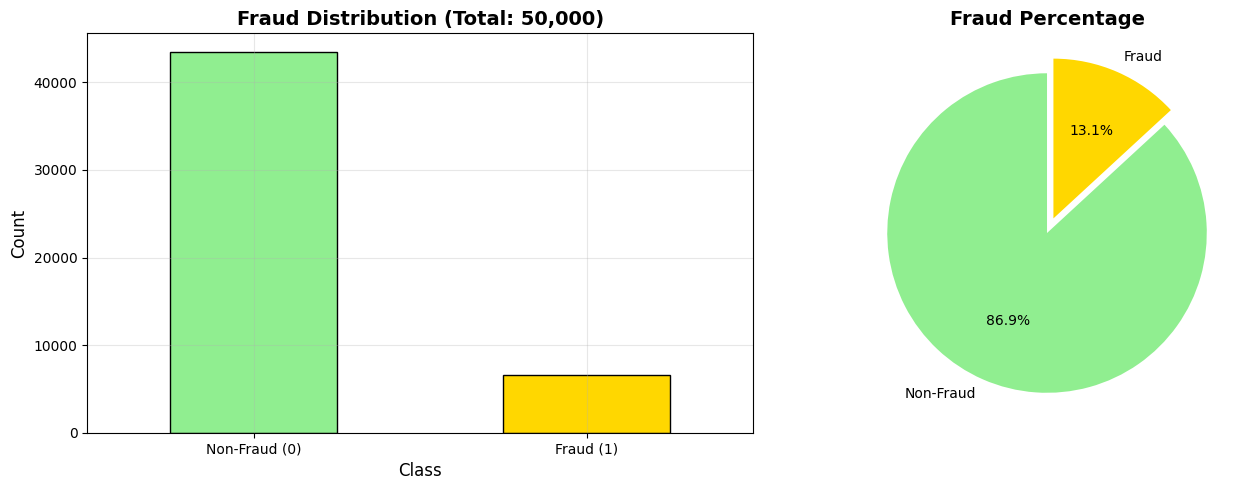

In [56]:
fraud_counts = df['Fraud'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts.plot(kind='bar', color=['lightgreen', 'gold'], edgecolor='black', ax=axes[0])
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Fraud Distribution (Total: {len(df):,})', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
axes[0].grid(alpha=0.3)

colors = ['lightgreen', 'gold']
axes[1].pie(fraud_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.1))
axes[1].set_title('Fraud Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribución de las variables numéricas

In [57]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'Fraud'],
      dtype='object')

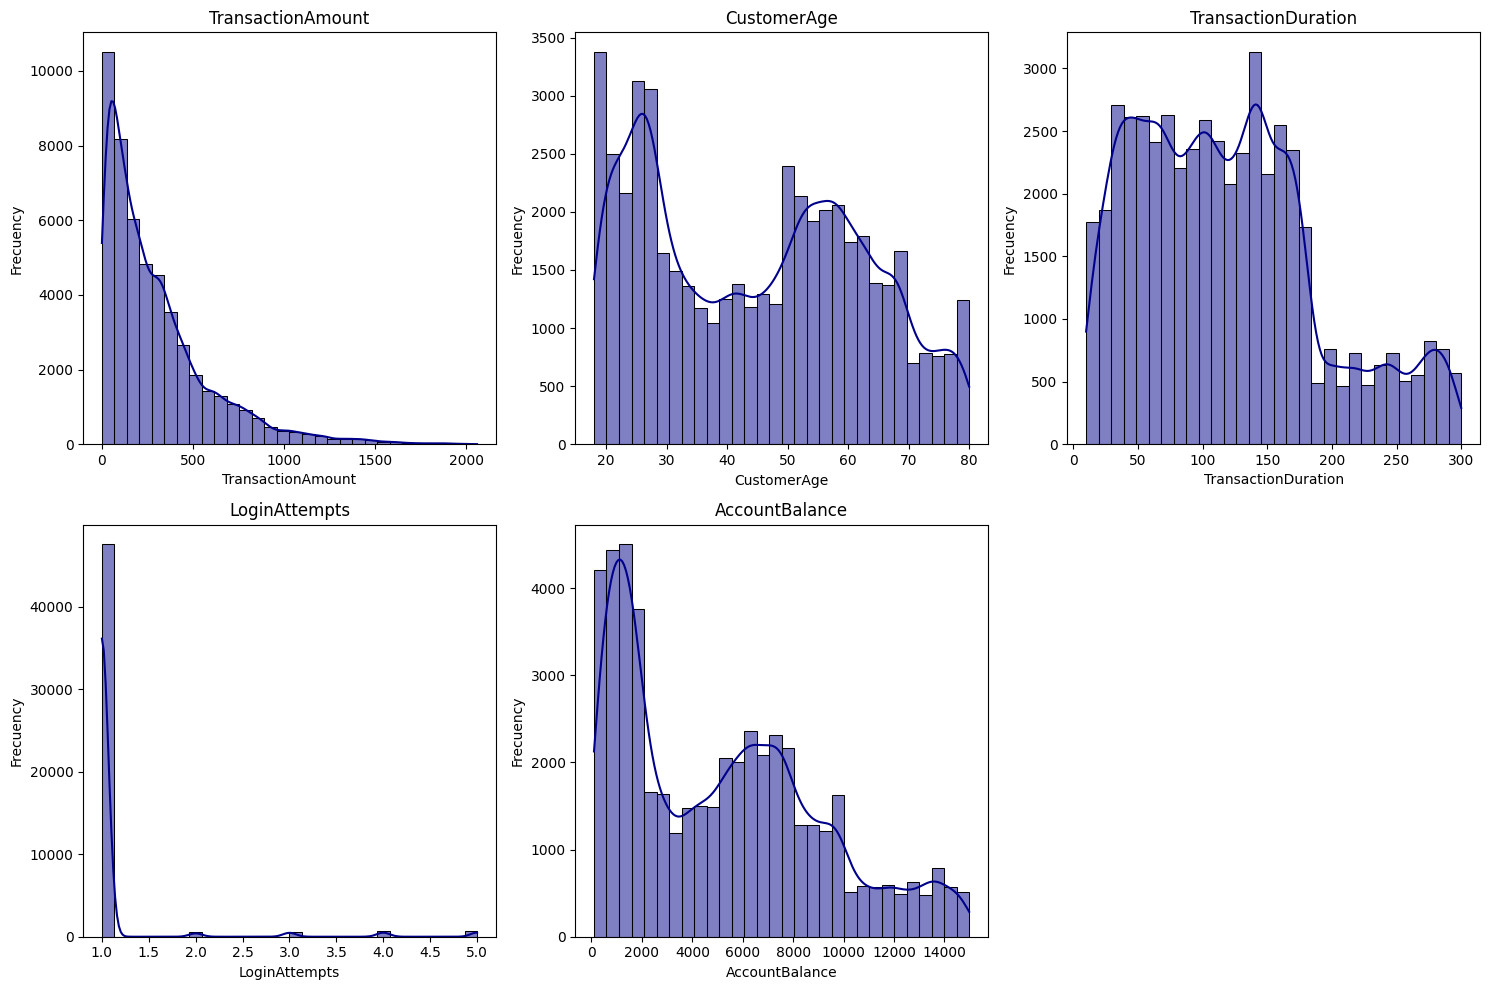

In [58]:
graph_var = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']

n_cols = 3
n_rows = (len(graph_var) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5*n_rows))

for i, col in enumerate(graph_var):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], bins=30, kde=True, color='darkblue')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frecuency')

plt.tight_layout()
plt.show()

In [59]:
fraud_amounts = df[df['Fraud'] == 1]['TransactionAmount']
non_fraud_amounts = df[df['Fraud'] == 0]['TransactionAmount']

print(f"Non-Fraud Transactions:")
print(f"   Mean: ${non_fraud_amounts.mean():.2f}")
print(f"   Median: ${non_fraud_amounts.median():.2f}")
print(f"   Std: ${non_fraud_amounts.std():.2f}")

print(f"\nFraud Transactions:")
print(f"   Mean: ${fraud_amounts.mean():.2f}")
print(f"   Median: ${fraud_amounts.median():.2f}")
print(f"   Std: ${fraud_amounts.std():.2f}")

Non-Fraud Transactions:
   Mean: $254.00
   Median: $197.55
   Std: $213.80

Fraud Transactions:
   Mean: $587.76
   Median: $371.98
   Std: $503.55


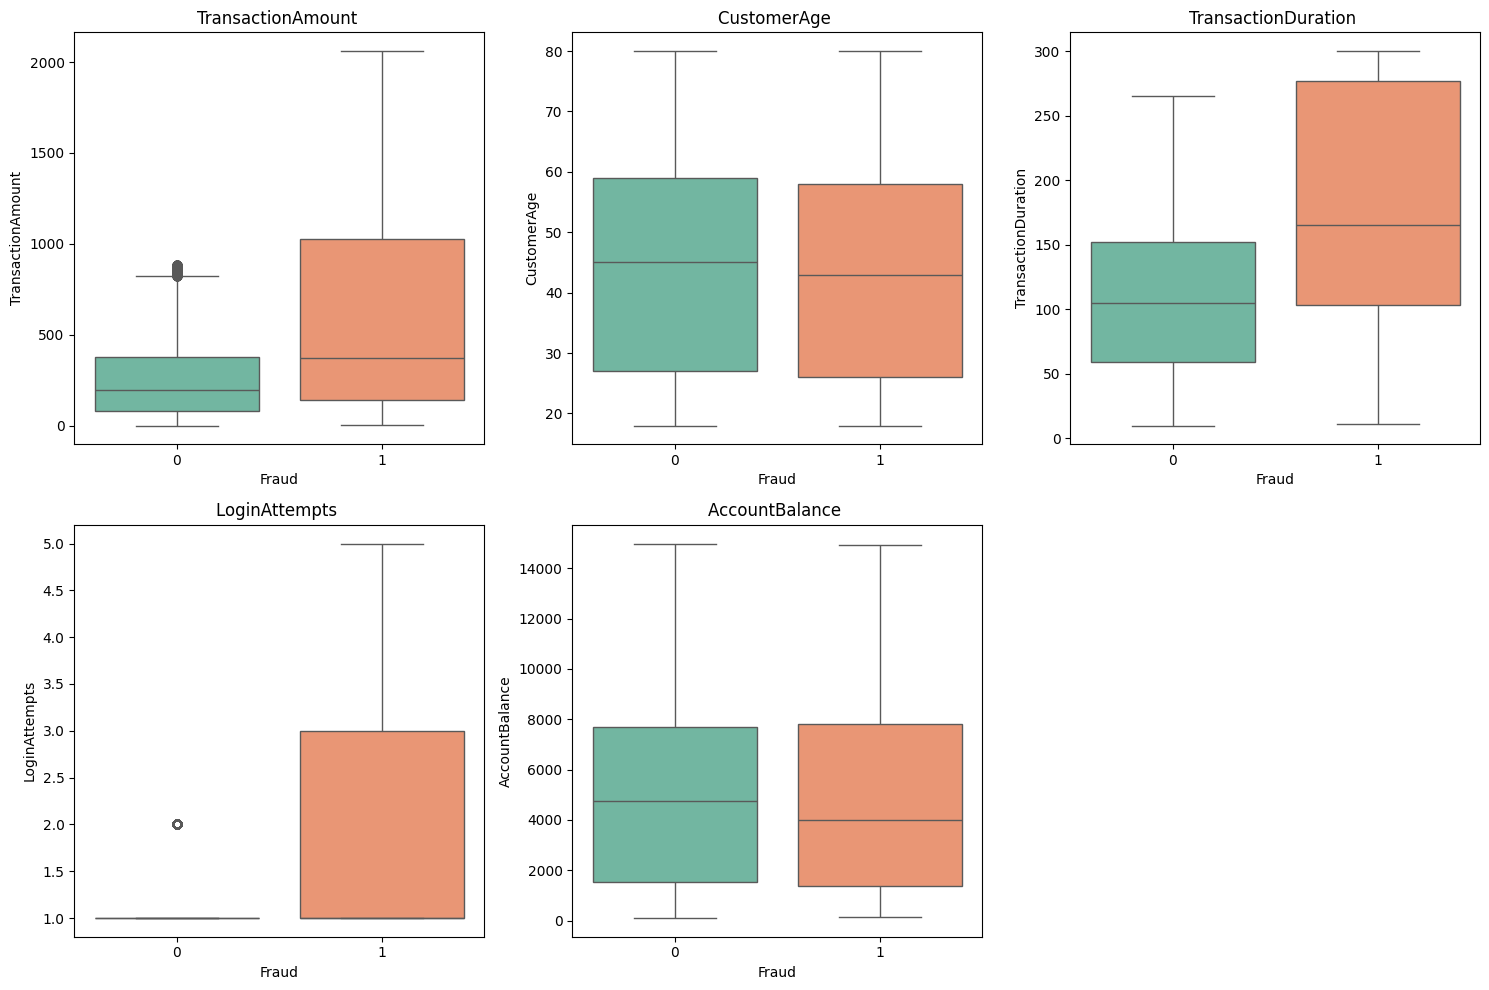

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i, var in enumerate(graph_var):
    sns.boxplot(x='Fraud', y=var, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"{var} ")

for j in range(len(graph_var), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Se analizó la distribución de las variables numéricas mediante histogramas y boxplots. Los resultados muestran que algunas variables presentan distribuciones asimétricas y la presencia de valores atípicos, particularmente en el monto de las transacciones y el balance de las cuentas. Estos valores extremos podrían estar asociados con comportamientos inusuales en las transacciones y potenciales casos de fraude.

### Distribución variables categoricas

In [61]:
df['TransactionType'].value_counts()

,count
TransactionType,
Debit,38747
Credit,11253


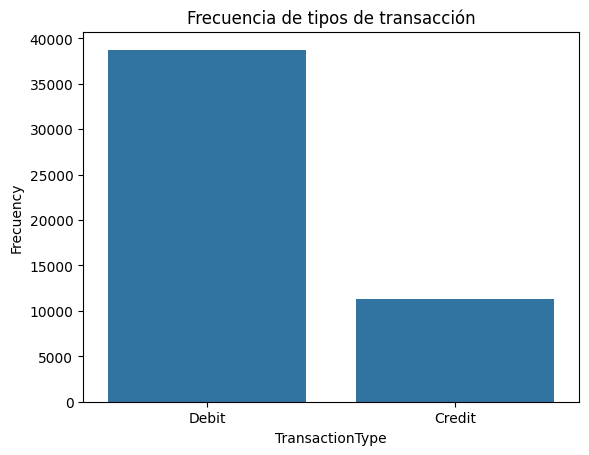

In [62]:
sns.countplot(x='TransactionType', data=df)
plt.title("Frecuencia de tipos de transacción")
plt.ylabel('Frecuency')
plt.show()

In [63]:
df['Channel'].value_counts()

,count
Channel,
Branch,17278
ATM,16552
Online,16170


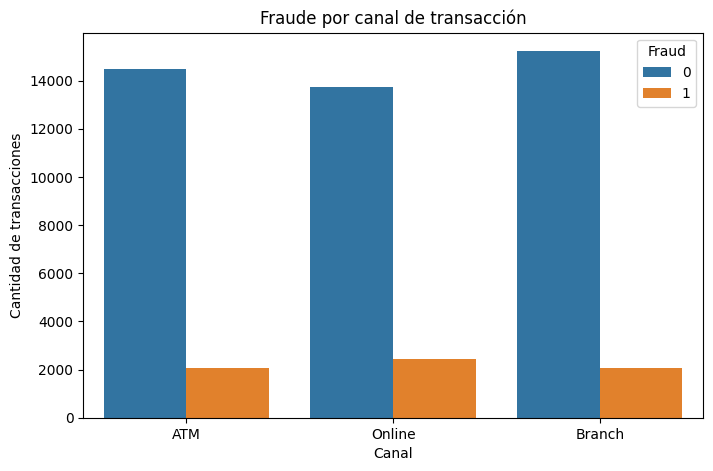

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(x='Channel', hue='Fraud', data=df)

plt.title("Fraude por canal de transacción")
plt.xlabel("Canal")
plt.ylabel("Cantidad de transacciones")

plt.show()

In [65]:
df['CustomerOccupation'].value_counts()

,count
CustomerOccupation,
Student,13059
Doctor,12578
Engineer,12491
Retired,11872


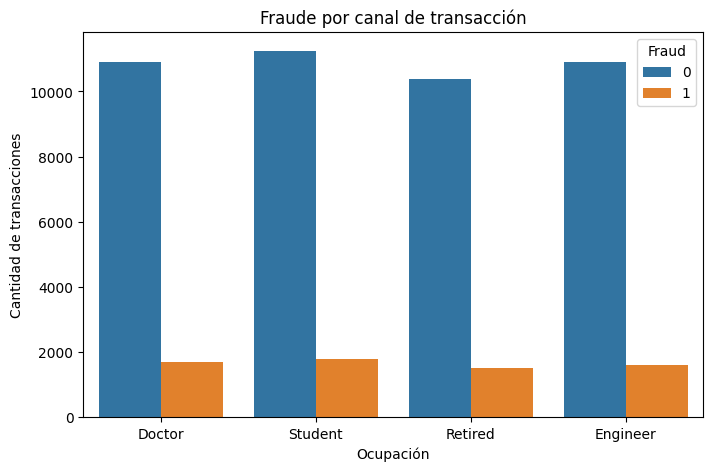

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(x='CustomerOccupation', hue='Fraud', data=df)

plt.title("Fraude por canal de transacción")
plt.xlabel("Ocupación")
plt.ylabel("Cantidad de transacciones")

plt.show()

### Relaciones entre variables

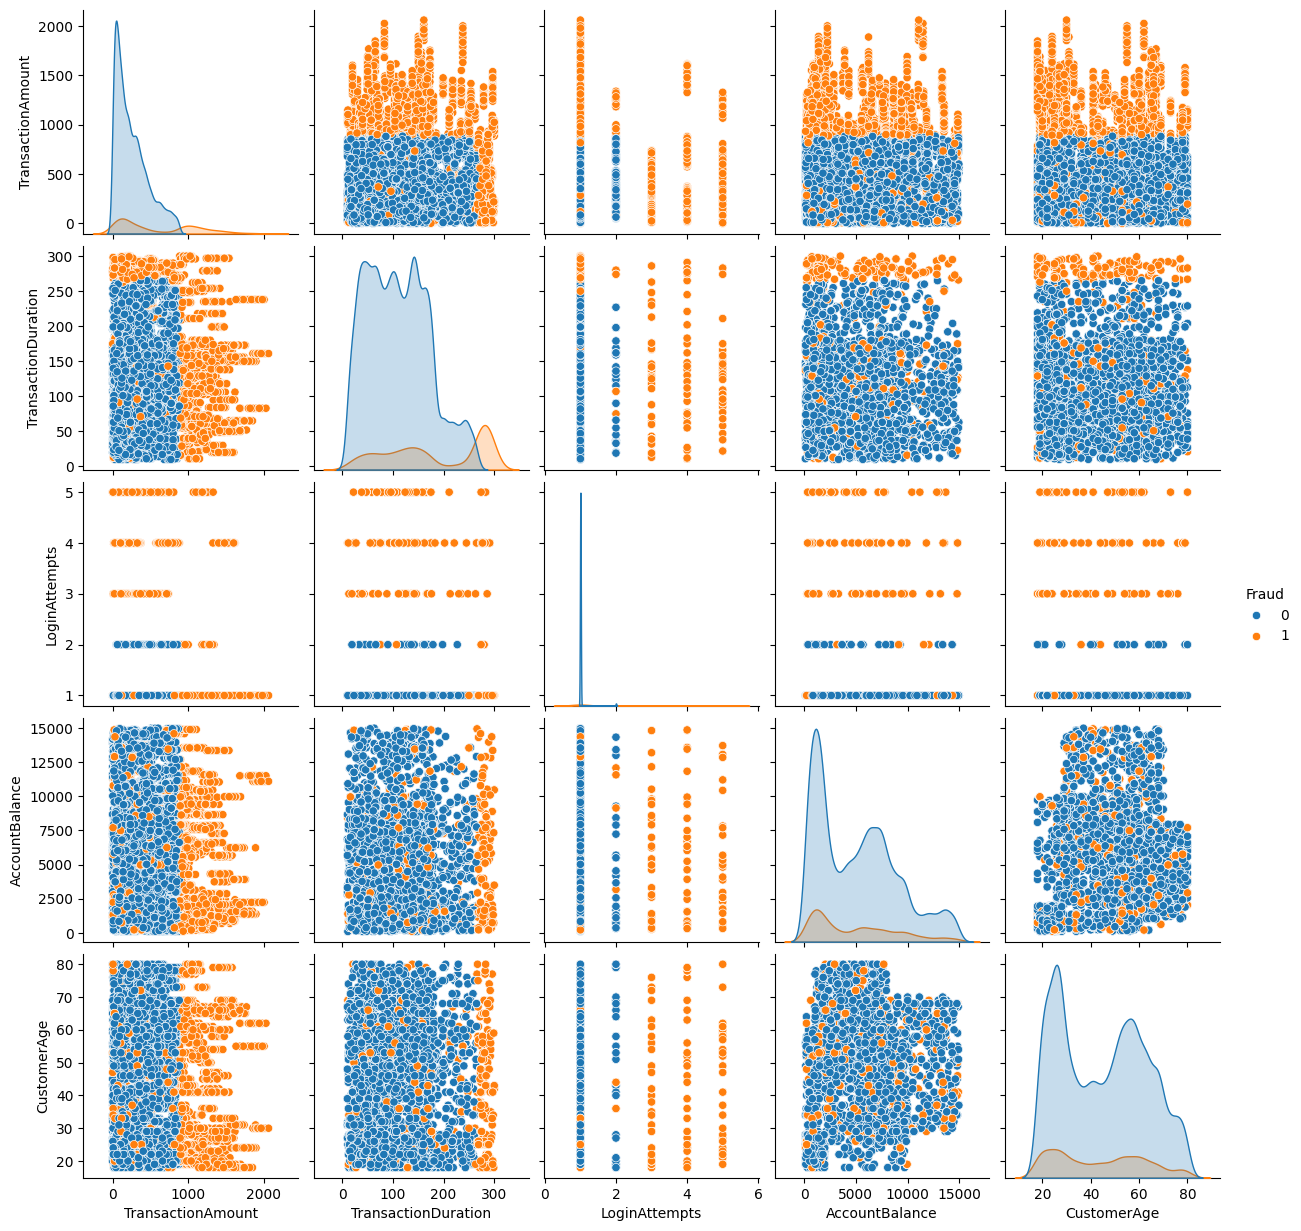

In [67]:
sns.pairplot(
    df[['TransactionAmount','TransactionDuration','LoginAttempts','AccountBalance','CustomerAge','Fraud']],
    hue='Fraud'
)

plt.show()

Se exploraron las relaciones entre las variables numéricas y categóricas mediante matrices de correlación, gráficos de dispersión y análisis cruzado con la variable de fraude. Los resultados muestran que variables como el monto de la transacción, la duración de la transacción y el número de intentos de login presentan patrones asociados con comportamientos anómalos, lo que las convierte en variables relevantes para el análisis y la detección de posibles fraudes.

In [68]:
df.corr(numeric_only=True)

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Fraud
TransactionAmount,1.000000,-0.020924,0.013444,-0.015235,-0.021406,0.385121
CustomerAge,-0.020924,1.000000,-0.015324,0.007693,0.319942,-0.025975
TransactionDuration,0.013444,-0.015324,1.000000,0.032914,0.006163,0.331819
LoginAttempts,-0.015235,0.007693,0.032914,1.000000,0.004979,0.490790
AccountBalance,-0.021406,0.319942,0.006163,0.004979,1.000000,-0.017002
Fraud,0.385121,-0.025975,0.331819,0.490790,-0.017002,1.000000


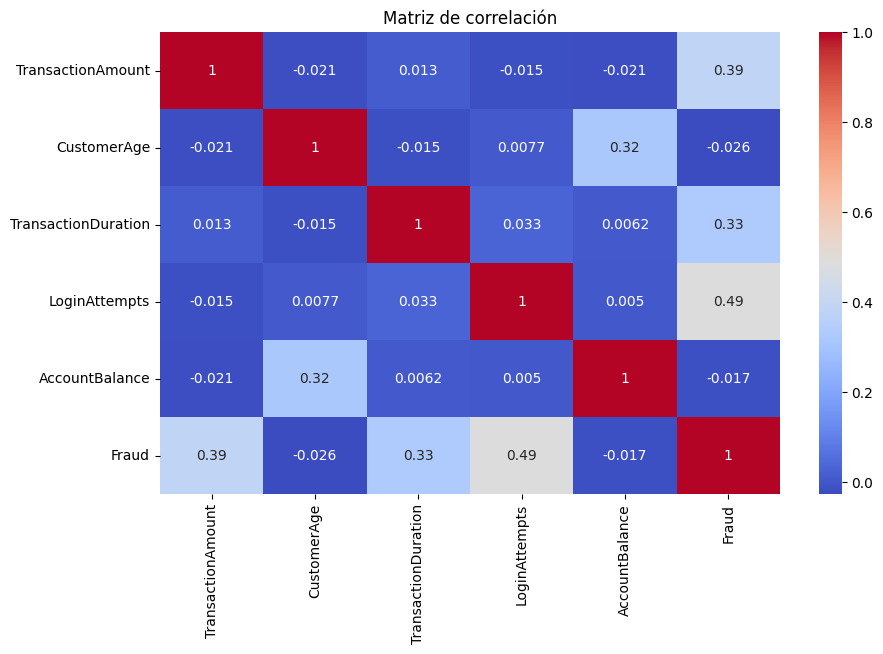

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

### Feature Engineering

In [70]:
#  La relación monto/saldo puede mostrar transacciones sospechosamente grandes.
df['ratio_monto_saldo'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)

# Los cliente con muchos intentos de login pueden indicar actividad sospechosa.
df['muchos_intentos_login'] = df['LoginAttempts'] > 3

# Transacciónes rápidas y grandes. Las transacciones fraudulentas muchas veces son montos grandes en poco tiempo.
df['monto_por_duracion'] = df['TransactionAmount'] / (df['TransactionDuration'] + 1)

# Cliente joven con transacción grande
df['monto_por_edad'] = df['TransactionAmount'] / df['CustomerAge']

# Cliente con saldo bajo pero transacción grande
df['transaccion_sospechosa'] = (
    df['TransactionAmount'] > df['AccountBalance'] * 0.8
)

#Categorizar monto de transacción. Crear niveles de monto ayuda a algunos modelos.
df['categoria_monto'] = pd.qcut(df['TransactionAmount'], q=4, labels=[
    'bajo', 'medio', 'alto', 'muy_alto'
])

# Cliente con alto riesgo. Se combinan dos comportamientos sospechosos.
df['riesgo_cliente'] = (
    (df['LoginAttempts'] > 3) &
    (df['TransactionAmount'] > df['TransactionAmount'].median())
)
# Monto promedio por ocupación. Esto permite ver si una transacción es alta para esa ocupación.
promedio_ocupacion = df.groupby('CustomerOccupation')['TransactionAmount'].transform('mean')
df['ratio_monto_ocupacion'] = df['TransactionAmount'] / promedio_ocupacion

Se generaron nuevas variables derivadas con el objetivo de capturar patrones potencialmente asociados al fraude. Estas variables incluyen relaciones entre el monto de la transacción y el saldo disponible, métricas basadas en el comportamiento del cliente y variables indicadoras de actividad sospechosa, como múltiples intentos de acceso.

In [71]:
corr = df.corr(numeric_only=True)

corr['Fraud'].sort_values(ascending=False)

,Fraud
Fraud,1.000000
LoginAttempts,0.490790
muchos_intentos_login,0.420823
TransactionAmount,0.385121
ratio_monto_ocupacion,0.384624
monto_por_edad,0.344402
TransactionDuration,0.331819
riesgo_cliente,0.274571
monto_por_duracion,0.160025
transaccion_sospechosa,0.131905


In [72]:
variables_finales = [
    'LoginAttempts',
    'TransactionAmount',
    'TransactionDuration',
    'ratio_monto_ocupacion',
    'monto_por_edad',
    'ratio_monto_saldo',
    'monto_por_duracion',
    'transaccion_sospechosa',
    'Fraud'
]

df_modelo = df[variables_finales]

Se seleccionaron las variables con mayor correlación con la variable objetivo Fraud, priorizando aquellas relacionadas con el monto de la transacción, el número de intentos de login y métricas derivadas de comportamiento financiero.

### Detección de anomalías

##### Identificación de valores atípicos (outliers)

In [73]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['TransactionAmount'] < limite_inferior) |
              (df['TransactionAmount'] > limite_superior)]

print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 2375


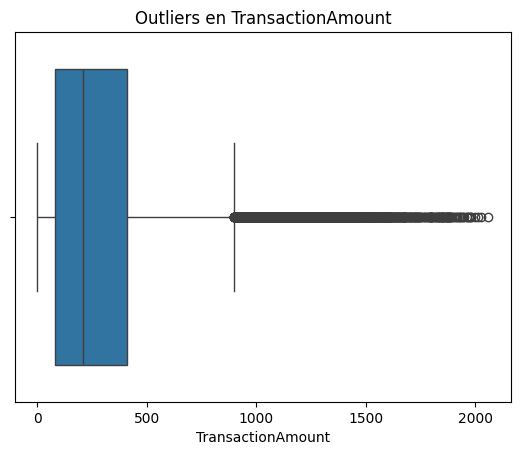

In [74]:
sns.boxplot(x=df['TransactionAmount'])
plt.title("Outliers en TransactionAmount")
plt.show()

Para detectar valores atípicos se utilizó el método del Rango Intercuartílico (IQR). Este método identifica observaciones que se encuentran fuera del rango definido por
𝑄
1
−
1.5
×
𝐼
𝑄
𝑅
Q1−1.5×IQR y
𝑄
3
+
1.5
×
𝐼
𝑄
𝑅
Q3+1.5×IQR.
Se aplicó principalmente sobre variables numéricas como el monto de la transacción, la duración y el saldo de la cuenta, ya que estas pueden presentar valores extremos asociados a comportamientos anómalos o potencialmente fraudulentos.

##### Detección de anomalías con Machine Learning

In [75]:
X = df_modelo.drop(columns=['Fraud'])

In [76]:
from sklearn.ensemble import IsolationForest

modelo_anomalias = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

modelo_anomalias.fit(X)

df_modelo['anomalia'] = modelo_anomalias.predict(X)

In [77]:
df_modelo['anomalia'] = df_modelo['anomalia'].map({1:0, -1:1})

In [78]:
df_modelo['anomalia'].value_counts()

,count
anomalia,
0,47500
1,2500


In [79]:
pd.crosstab(df_modelo['Fraud'], df_modelo['anomalia'])

anomalia,0,1
Fraud,,
0,42586,842
1,4914,1658


0 → transacciones normales

1 → transacciones anómalas

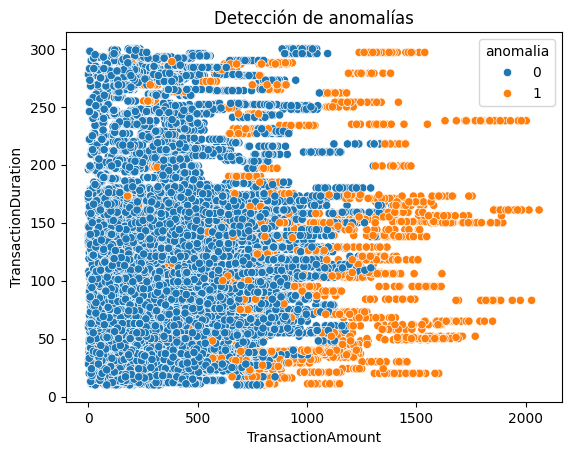

In [80]:
sns.scatterplot(
    x=df_modelo['TransactionAmount'],
    y=df_modelo['TransactionDuration'],
    hue=df_modelo['anomalia']
)

plt.title("Detección de anomalías")
plt.show()

Para la detección de anomalías se aplicó el algoritmo Isolation Forest, un método de aprendizaje automático diseñado para identificar observaciones inusuales dentro de un conjunto de datos. Las observaciones clasificadas como anomalías pueden representar transacciones potencialmente fraudulentas o comportamientos financieros atípicos.

### Análisis de resultados

In [81]:
df_modelo.groupby('anomalia').mean(numeric_only=True)

,LoginAttempts,TransactionAmount,TransactionDuration,ratio_monto_ocupacion,monto_por_edad,ratio_monto_saldo,monto_por_duracion,transaccion_sospechosa,Fraud
anomalia,,,,,,,,,
0,1.123726,260.807641,118.671305,0.878106,6.770093,0.127461,3.401120,0.024253,0.103453
1,1.186000,1002.099100,124.551600,3.315986,34.160418,1.504119,14.742513,0.664000,0.663200


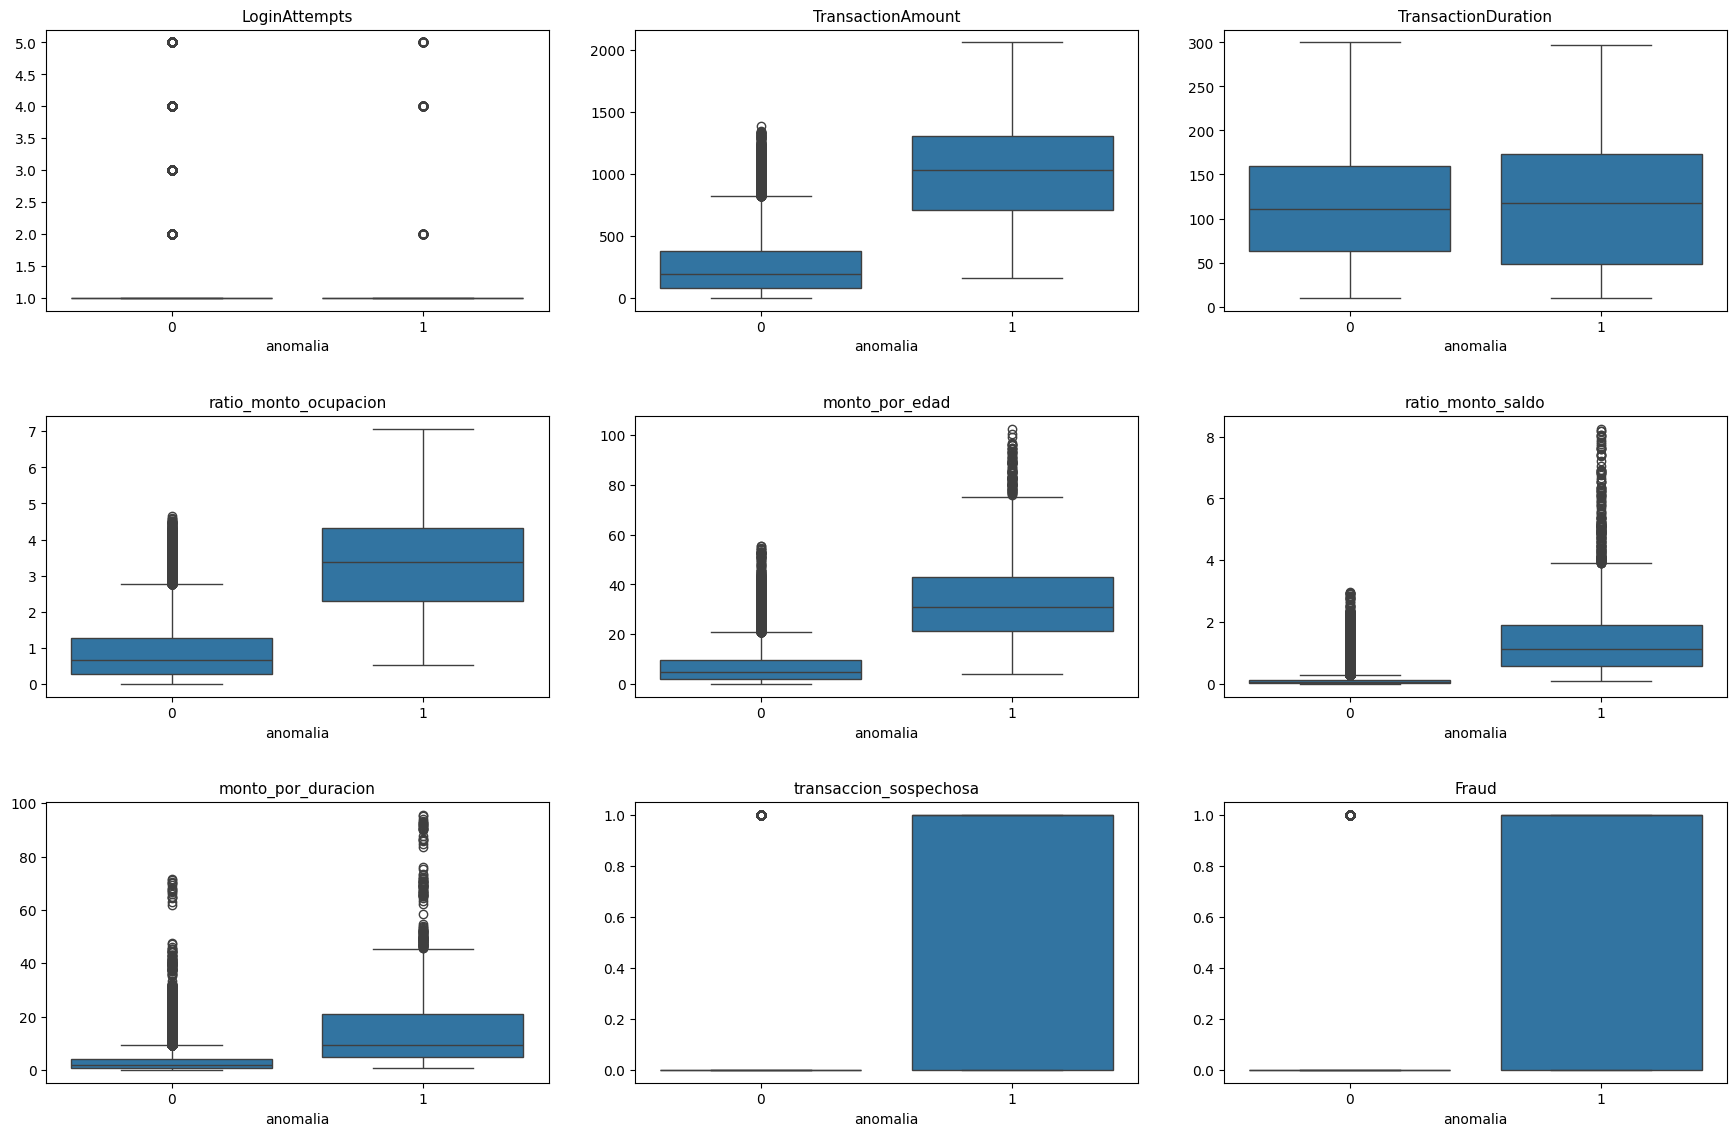

In [82]:
fig, axes = plt.subplots(3,3, figsize=(18,12))
axes = axes.flatten()

for i, var in enumerate(variables_finales):

    sns.boxplot(
        x='anomalia',
        y=var,
        data=df_modelo,
        ax=axes[i]
    )

    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel("anomalia")
    axes[i].set_ylabel("")

plt.tight_layout(pad=3)
plt.show()

Se analizaron las características de las transacciones clasificadas como anómalas por el modelo de detección de anomalías. Se observó que estas transacciones tienden a presentar montos más elevados, mayor número de intentos de acceso y valores más altos en las métricas de riesgo generadas durante el proceso de ingeniería de variables. Además, se identificó que una proporción significativa de estas transacciones coincide con los registros de fraude presentes en el dataset, lo que sugiere que el modelo logra identificar comportamientos potencialmente sospechosos.

### Visualización e interpretación

In [83]:
df_modelo.groupby('anomalia').mean(numeric_only=True)

,LoginAttempts,TransactionAmount,TransactionDuration,ratio_monto_ocupacion,monto_por_edad,ratio_monto_saldo,monto_por_duracion,transaccion_sospechosa,Fraud
anomalia,,,,,,,,,
0,1.123726,260.807641,118.671305,0.878106,6.770093,0.127461,3.401120,0.024253,0.103453
1,1.186000,1002.099100,124.551600,3.315986,34.160418,1.504119,14.742513,0.664000,0.663200


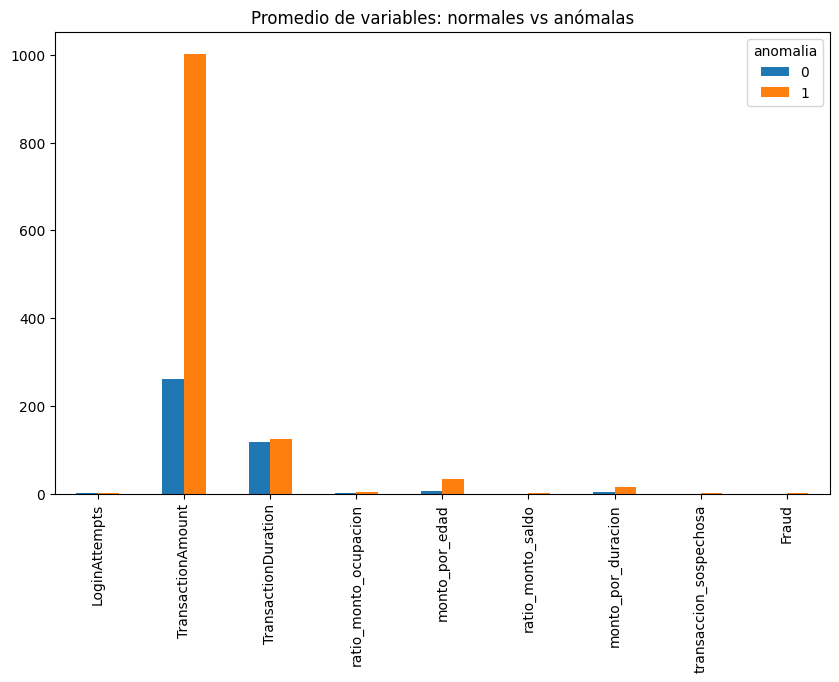

In [84]:
df_modelo.groupby('anomalia').mean(numeric_only=True).T.plot(kind='bar', figsize=(10,6))
plt.title("Promedio de variables: normales vs anómalas")
plt.show()

A partir del análisis de las transacciones clasificadas como anómalas, se identificó que las variables que presentan mayores diferencias respecto a las transacciones normales son el monto de la transacción y la duración. Estas variables parecen ser las que más influyen en la detección de anomalías por parte del modelo.